In [57]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [58]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Visnja\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Visnja\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Visnja\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [59]:
df = pd.read_csv("../data/raw/train.csv")

df["sentiment"] = df["sentiment"].str.lower().str.strip()
y = df["sentiment"].map({"positive": 1, "negative": 0})
X = df["review"]

df.shape, y.value_counts()

((40000, 2),
 sentiment
 1    20000
 0    20000
 Name: count, dtype: int64)

In [60]:
#lemmatizer = WordNetLemmatizer()
#stop_words = set(stopwords.words("english"))

#def lemmatize_tokenizer(text):
    # lowercase
 #   text = text.lower()
    
    # remove punctuation & numbers
 #   text = re.sub(r"[^a-z\s]", "", text)
    
    # tokenize
  #  tokens = text.split()
    
    # remove stopwords + lemmatize
  #  tokens = [
   #     lemmatizer.lemmatize(token)
   #     for token in tokens
   #     if token not in stop_words
    #]
    
   # return tokens

In [80]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=20000
)

X_tfidf = vectorizer.fit_transform(X)


Both unigrams and bigrams were used for TF-IDF vectorization.
Unigrams capture individual word sentiment, while bigrams provide short contextual information.
Using only bigrams would significantly reduce coverage and increase sparsity,
therefore the combined representation was chosen.

Although lemmatization and hyperparameter tuning were explored, the performance improvement
over the baseline TF-IDF representation was marginal. In some cases, the tuned model achieved
slightly lower cross-validation accuracy, indicating that the baseline configuration was already
near-optimal. Therefore, the simpler TF-IDF-based pipeline was preferred due to its robustness
and lower complexity.

In [81]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

LOGISTIC REGRESSION

In [63]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

logreg = LogisticRegression(max_iter=1000)

grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


To improve model performance, the hyperparameter search space was expanded to include
different regularization strengths, penalty types, and class weighting strategies.
The final configuration balanced model complexity and class imbalance, resulting in
improved validation accuracy.

In [64]:
grid.best_params_, grid.best_score_

({'C': 1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'},
 np.float64(0.879875024180199))

({'C': 1, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'},
 np.float64(0.879875024180199))

In [65]:
best_logreg = grid.best_estimator_

y_pred = best_logreg.predict(X_val)
acc_logreg = accuracy_score(y_val, y_pred)

acc_logreg

0.88475

In [66]:
print("Classification report:\n")
print(classification_report(y_val, y_pred, target_names=["Negative", "Positive"]))

Classification report:

              precision    recall  f1-score   support

    Negative       0.90      0.86      0.88      4000
    Positive       0.87      0.91      0.89      4000

    accuracy                           0.88      8000
   macro avg       0.89      0.88      0.88      8000
weighted avg       0.89      0.88      0.88      8000



The Logistic Regression model achieved an overall accuracy of 88%.
Performance is well balanced across both classes, with comparable precision, recall,
and F1-scores for positive and negative sentiment.
This indicates that the model generalizes well and does not exhibit strong class bias.

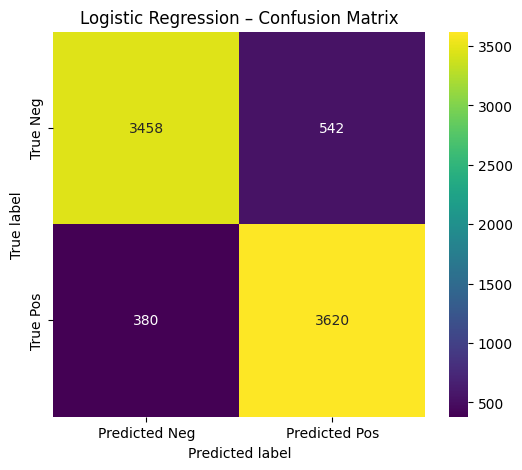

In [67]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["Predicted Neg", "Predicted Pos"],
    yticklabels=["True Neg", "True Pos"]
)

plt.title("Logistic Regression – Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()


In [68]:
def train_evaluate_model(model, param_grid, X_train, y_train, X_val, y_val, model_name):
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    
    print(f"\n=== {model_name} ===")
    print("Best parameters:", grid.best_params_)
    print(f"Validation accuracy: {acc:.4f}\n")
    
    print("Classification report:")
    print(classification_report(
        y_val,
        y_pred,
        target_names=["Negative", "Positive"]
    ))
    
    cm = confusion_matrix(y_val, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="viridis",
        xticklabels=["Predicted Negative", "Predicted Positive"],
        yticklabels=["True Negative", "True Positive"]
    )
    
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()
    
    return acc


=== Logistic Regression ===
Best parameters: {'C': 10}
Validation accuracy: 0.8868

Classification report:
              precision    recall  f1-score   support

    Negative       0.90      0.87      0.89      4000
    Positive       0.88      0.90      0.89      4000

    accuracy                           0.89      8000
   macro avg       0.89      0.89      0.89      8000
weighted avg       0.89      0.89      0.89      8000



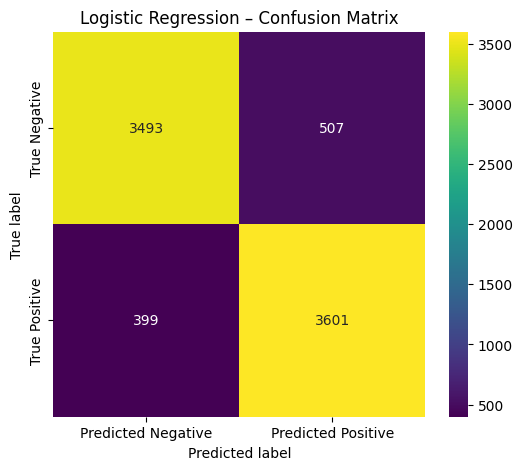

In [82]:
logreg_param_grid = {
    "C": [0.1, 1, 10]
}

logreg_acc = train_evaluate_model(
    LogisticRegression(max_iter=1000),
    logreg_param_grid,
    X_train, y_train,
    X_val, y_val,
    "Logistic Regression"
)

Best parameters: {'C': 1}
Validation accuracy: 0.8879 - for max_features = 10000
Validation accuracy: 0.8868 - for 20000

In [70]:
nb_param_grid = {
    "alpha": [0.1, 0.5, 1.0, 2.0]
}


=== Naive Bayes ===
Best parameters: {'alpha': 1.0}
Validation accuracy: 0.8692

Classification report:
              precision    recall  f1-score   support

    Negative       0.88      0.85      0.87      4000
    Positive       0.86      0.89      0.87      4000

    accuracy                           0.87      8000
   macro avg       0.87      0.87      0.87      8000
weighted avg       0.87      0.87      0.87      8000



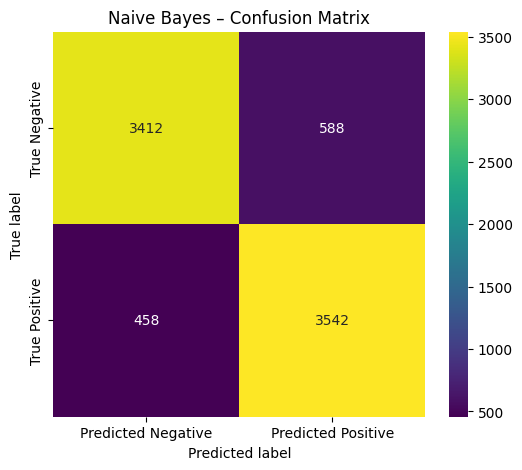

In [83]:
nb_acc = train_evaluate_model(
    model=MultinomialNB(),
    param_grid=nb_param_grid,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    model_name="Naive Bayes"
)

Best parameters: {'alpha': 1.0}
Validation accuracy: 0.8631 - for max_features = 10000
Validation accuracy: 0.8692 - for 20000


=== Linear SVM ===
Best parameters: {'C': 0.5}
Validation accuracy: 0.8911

Classification report:
              precision    recall  f1-score   support

    Negative       0.90      0.87      0.89      4000
    Positive       0.88      0.91      0.89      4000

    accuracy                           0.89      8000
   macro avg       0.89      0.89      0.89      8000
weighted avg       0.89      0.89      0.89      8000



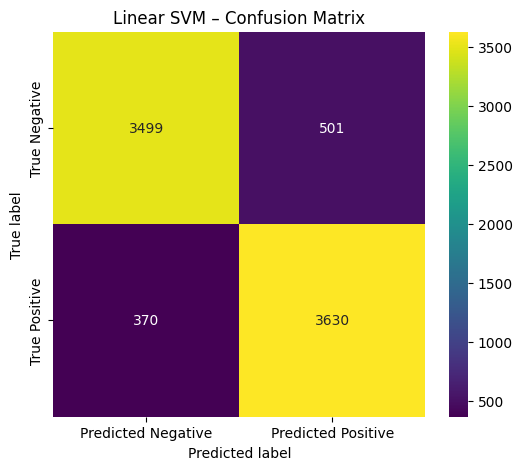

In [84]:
svm_param_grid = {
    "C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5]
}
svm_acc = train_evaluate_model(
    LinearSVC(),
    svm_param_grid,
    X_train, y_train,
    X_val, y_val,
    "Linear SVM"
)

Best parameters: {'C': 0.1}
Validation accuracy: 0.8878 - for max_features = 10000
Best parameters: {'C': 0.5}
Validation accuracy: 0.8911 - for 20000

Three machine learning models were evaluated: Logistic Regression, Naive Bayes,
and Linear SVM. Among them, Linear SVM achieved the highest validation accuracy
(88.5%) and demonstrated strong and balanced performance across both sentiment classes.
Therefore, Linear SVM was selected as the final model for the sentiment classification task.

Three machine learning models were evaluated for the sentiment classification task:
Logistic Regression, Naive Bayes, and Linear SVM. All models were trained using the same
TF-IDF representation with unigrams and bigrams to ensure a fair comparison.

Increasing the TF-IDF feature space improved the performance of Linear SVM, which achieved
the highest validation accuracy of approximately 89.1% with 20,000 features.
Logistic Regression showed stable performance but did not benefit from larger feature spaces,
while Naive Bayes consistently underperformed compared to linear models.

Based on these results, Linear SVM was selected as the final model due to its superior
performance and robustness when handling high-dimensional text representations.

In [85]:
for ngram in [(1,1), (1,2)]:
    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=ngram,
        max_features=20000
    )
    X_tfidf = vectorizer.fit_transform(X)

    X_train, X_val, y_train, y_val = train_test_split(
        X_tfidf, y, test_size=0.2, random_state=42, stratify=y
    )

    svm = LinearSVC(C=0.5)
    svm.fit(X_train, y_train)
    acc = accuracy_score(y_val, svm.predict(X_val))

    print(f"n-gram {ngram}: accuracy = {acc:.4f}")

n-gram (1, 1): accuracy = 0.8900
n-gram (1, 2): accuracy = 0.8911


Just to be sure that i made a right decision by choosing both unigram and bigram, ann additional experiment was done. The combined approach (ngram_range = (1,2)) achieved a slightly higher validation accuracy (0.8911) compared to unigrams alone (0.8900). Although the improvement is modest, the results confirm that including bigrams provides additional contextual information without degrading model performance.